<a href="https://colab.research.google.com/github/MahsanGhalami/Fundamentals-of-Intelligent-Systems-4041/blob/main/Q5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [ ]:
df = pd.read_csv("Housing.csv")

2-1

In [ ]:
df.shape

(545, 13)

2-2

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


2-3

In [ ]:
print(df.nunique())
for i in df.columns[2:]:
  print(f"{i} : {df[i].unique()}")


price               219
area                284
bedrooms              6
bathrooms             4
stories               4
mainroad              2
guestroom             2
basement              2
hotwaterheating       2
airconditioning       2
parking               4
prefarea              2
furnishingstatus      3
dtype: int64
bedrooms : [4 3 5 2 6 1]
bathrooms : [2 4 1 3]
stories : [3 4 2 1]
mainroad : ['yes' 'no']
guestroom : ['no' 'yes']
basement : ['no' 'yes']
hotwaterheating : ['no' 'yes']
airconditioning : ['yes' 'no']
parking : [2 3 0 1]
prefarea : ['yes' 'no']
furnishingstatus : ['furnished' 'semi-furnished' 'unfurnished']


3-1

In [ ]:
df.head(5)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


3-2

In [ ]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numerial", num_cols)
print("Categorial:", cat_cols)


Numerial ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']
Categorial: ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']


3-3

/tmp/ipython-input-3941414138.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette='Set2')
/tmp/ipython-input-3941414138.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette='Set2')
/tmp/ipython-input-3941414138.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette='Set2')
/tmp/ipython-input-3941414138.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effe

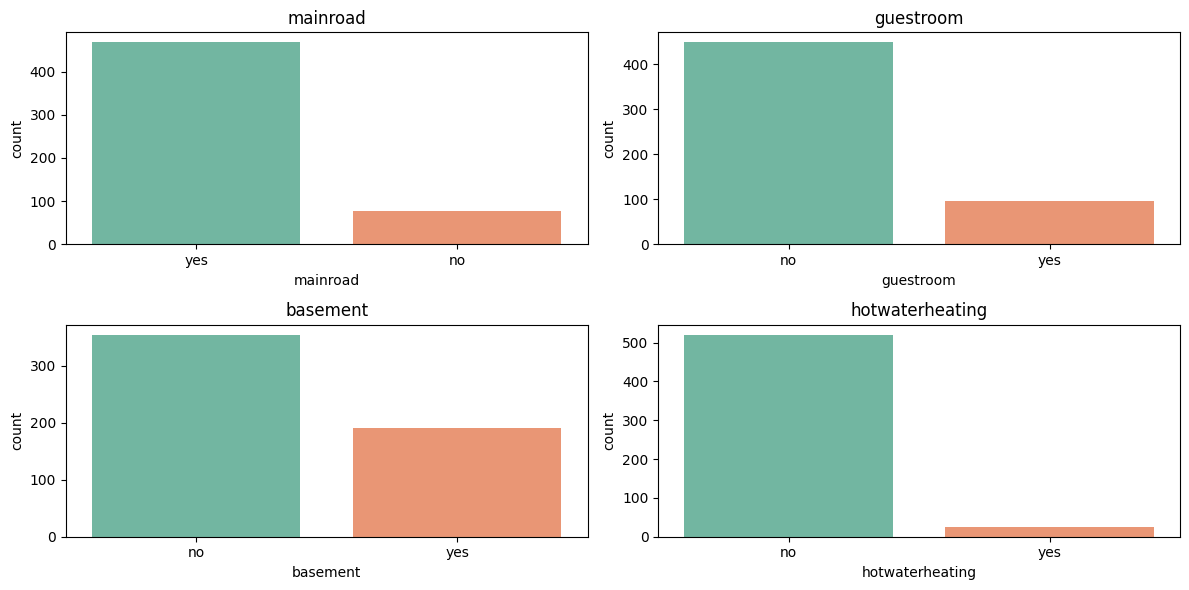

In [ ]:
plt.figure(figsize=(12,6))
for i, col in enumerate(cat_cols[:4]):
    plt.subplot(2,2,i+1)
    sns.countplot(x=df[col], palette='Set2')
    plt.title(col)
plt.tight_layout()
plt.show()

3-4

/tmp/ipython-input-497679425.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col], kde=True, color='blue')
/tmp/ipython-input-497679425.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col], kde=True, color='blue')
/tmp/ipython-input-497679425.py:4: UserWarning: 

`distplot` is a de

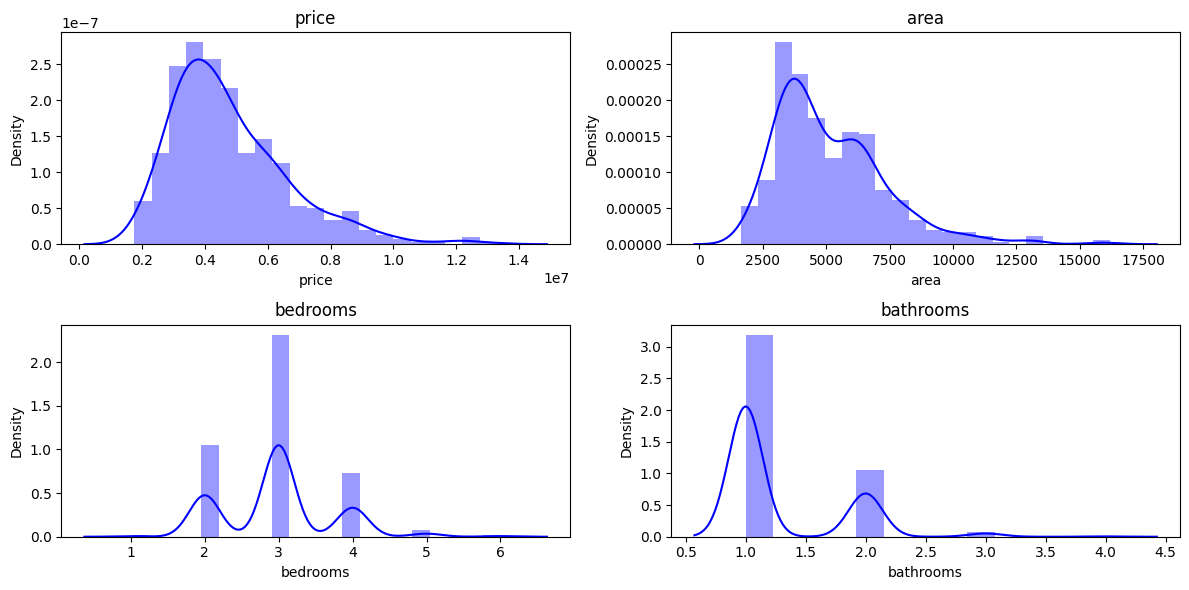

In [ ]:
plt.figure(figsize=(12,6))
for i, col in enumerate(num_cols[:4]):
    plt.subplot(2,2,i+1)
    sns.distplot(df[col], kde=True, color='blue')
    plt.title(col)
plt.tight_layout()
plt.show()


3-5

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable h

<Figure size 1200x600 with 0 Axes>

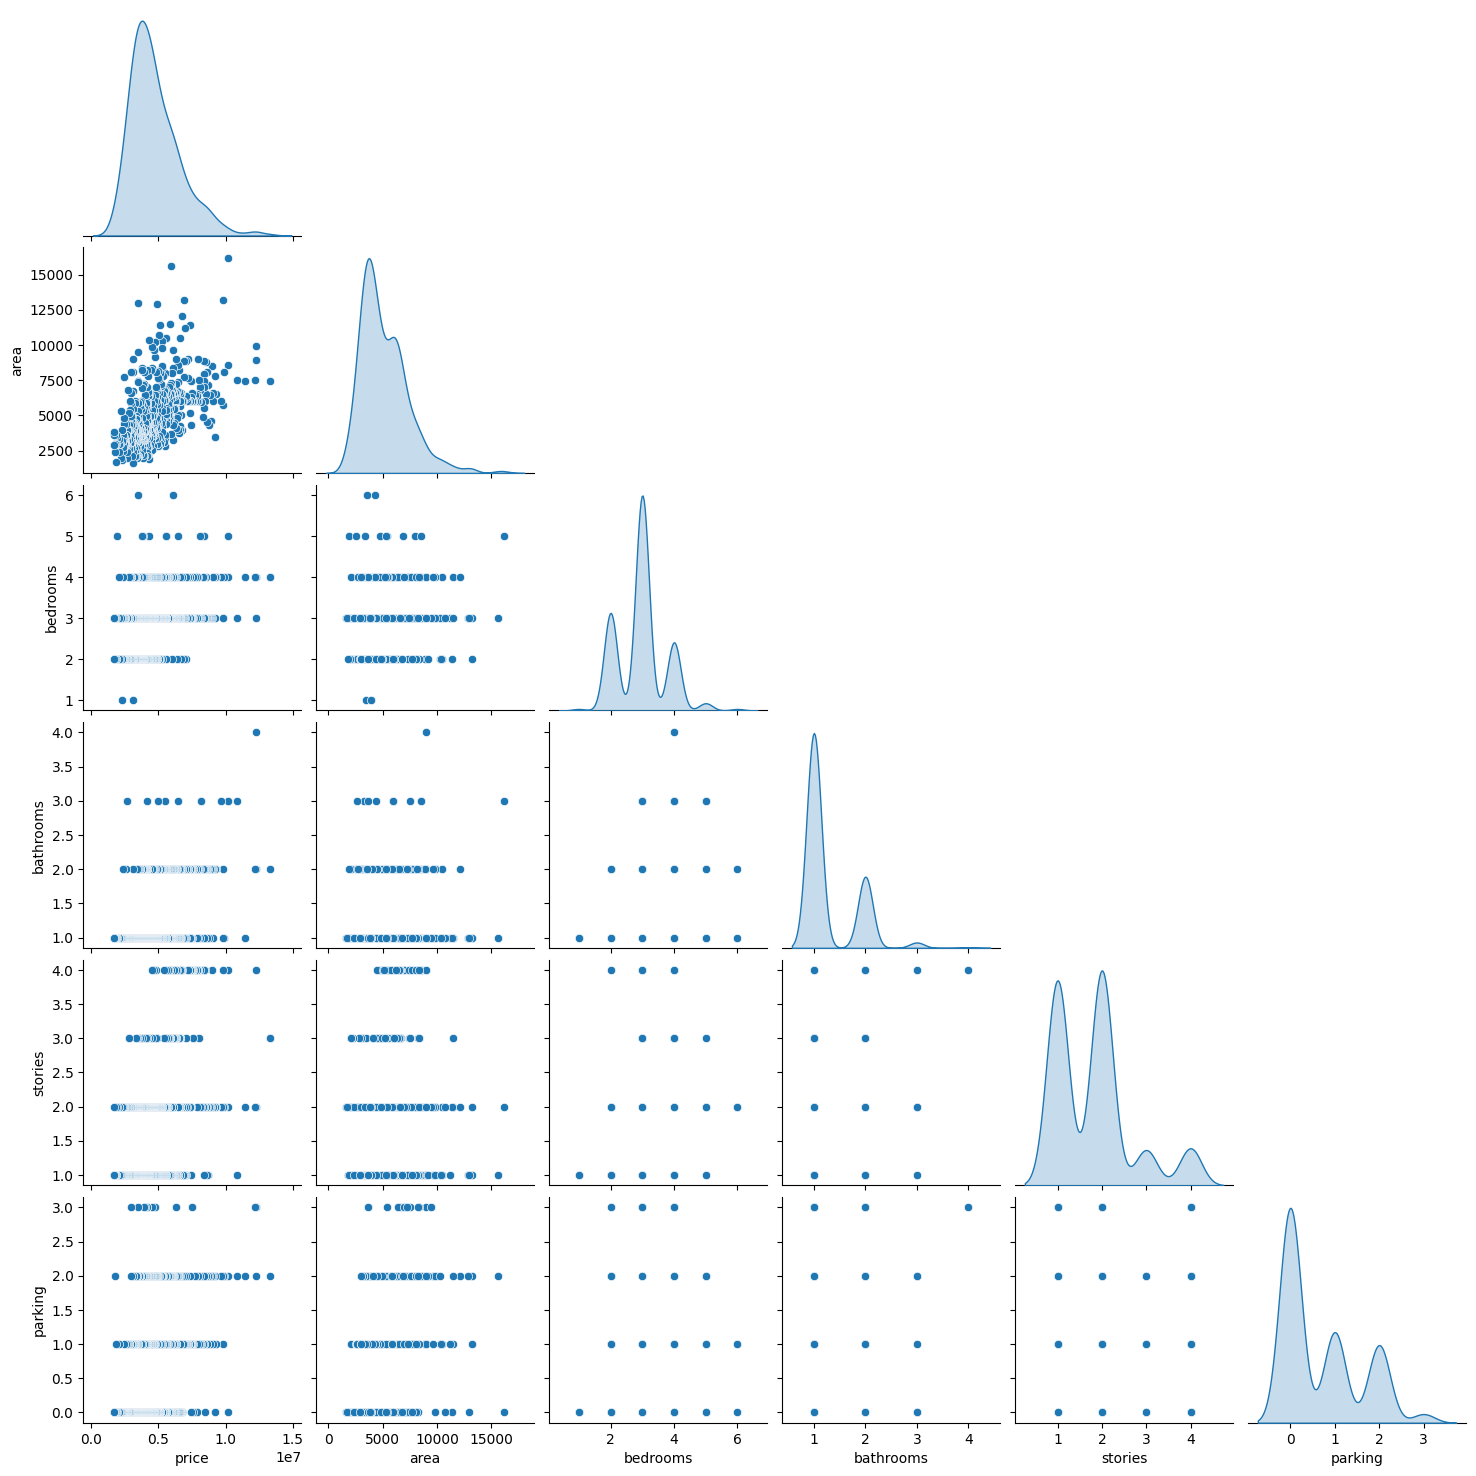

In [ ]:
plt.figure(figsize=(12,6))
sns.pairplot(df[num_cols], diag_kind='kde', corner=True, palette='Set2')
plt.show()


4-1

In [ ]:
df.duplicated().sum()

np.int64(0)

4-2

In [ ]:
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [ ]:
df_out = df.copy()

for col in ['price', 'area']:
    Q1 = df_out[col].quantile(0.25)
    Q3 = df_out[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    before = df_out.shape[0]
    df_out = df_out[(df_out[col] >= lower) & (df_out[col] <= upper)]
    after = df_out.shape[0]
    print(f"{col}: {before - after} outlier is deleted")


price: 15 outlier is deleted
area: 13 outlier is deleted


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,StandardScaler

X = df_out.drop('price', axis=1)
y = df_out['price']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), cat_cols),
        ('num', StandardScaler(), num_cols[1:len(num_cols)])
    ]
)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()
feature_names

array(['cat__mainroad_yes', 'cat__guestroom_yes', 'cat__basement_yes',
       'cat__hotwaterheating_yes', 'cat__airconditioning_yes',
       'cat__prefarea_yes', 'cat__furnishingstatus_semi-furnished',
       'cat__furnishingstatus_unfurnished', 'num__area', 'num__bedrooms',
       'num__bathrooms', 'num__stories', 'num__parking'], dtype=object)

5-1

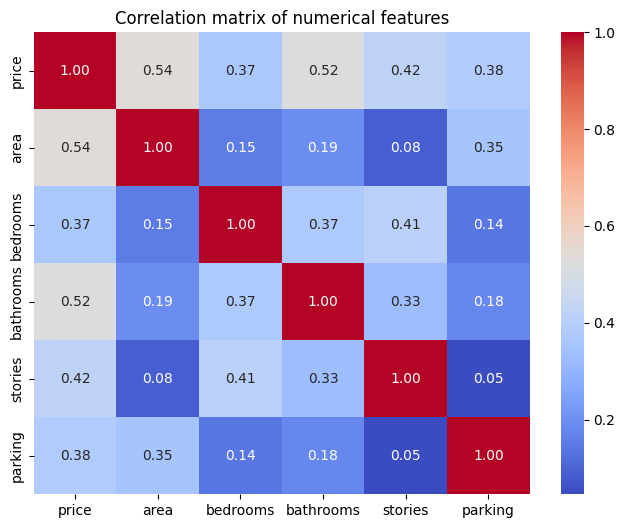

In [ ]:
corr = df[num_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation matrix of numerical features")
plt.show()


In [ ]:
from sklearn.decomposition import PCA

pca = PCA()
X_train_pca = pca.fit_transform(X_train)

explained = pca.explained_variance_ratio_

# واریانس تجمعی
cumulative = np.cumsum(explained)

pca_df = pd.DataFrame({
    'Component': [f'PC{i+1}' for i in range(len(explained))],
    'Explained Variance (%)': explained * 100,
    'Cumulative (%)': cumulative * 100
})

pca_df

,Component,Explained Variance (%),Cumulative (%)
0,PC1,29.269385,29.269385
1,PC2,19.170236,48.439621
2,PC3,11.643198,60.082819
3,PC4,10.972616,71.055435
4,PC5,9.176684,80.232119
5,PC6,5.538054,85.770173
6,PC7,3.947151,89.717324
7,PC8,2.719810,92.437134
8,PC9,2.307297,94.744431
9,PC10,1.717286,96.461716


In [ ]:
loadings = pd.DataFrame(
    pca.components_,
    columns =feature_names,
    index = [f"PC{i+1}" for i in range(len(pca.components_))]
)
loadings

,cat__mainroad_yes,cat__guestroom_yes,cat__basement_yes,cat__hotwaterheating_yes,cat__airconditioning_yes,cat__prefarea_yes,cat__furnishingstatus_semi-furnished,cat__furnishingstatus_unfurnished,num__area,num__bedrooms,num__bathrooms,num__stories,num__parking
PC1,0.048197,0.042241,0.011784,0.010982,0.120767,0.041064,0.042228,-0.082762,0.346683,0.541132,0.484460,0.495167,0.278971
PC2,0.089963,0.030196,-0.005964,-0.001172,0.044976,0.050330,0.010674,-0.027683,0.593262,-0.256208,-0.218732,-0.317902,0.647313
PC3,-0.059405,0.054631,0.191337,0.012454,-0.070345,-0.000763,0.086180,-0.051538,-0.122151,-0.044499,0.736401,-0.616506,0.049217
PC4,-0.053710,-0.093261,-0.030085,0.018438,-0.069591,-0.057420,0.086233,-0.069709,-0.668527,0.218701,-0.145894,0.009834,0.671265
PC5,-0.023088,0.057327,0.166051,0.002409,-0.076098,0.048924,0.057776,-0.037899,0.139488,0.747977,-0.368197,-0.457016,-0.179674
PC6,0.040317,0.059445,0.130561,0.018662,0.007524,0.004458,0.696577,-0.669415,0.016398,-0.134158,-0.086104,0.090272,-0.101013
PC7,0.109464,0.365090,0.704120,-0.054206,0.376548,0.343400,-0.212737,-0.007640,-0.150088,-0.090269,-0.087549,0.102170,0.046884
PC8,-0.164332,-0.128323,-0.227382,-0.079320,0.880162,-0.282649,-0.009429,-0.096660,-0.044131,0.051622,-0.007286,-0.167955,-0.040639
PC9,0.344225,-0.376598,-0.304254,-0.031525,0.136508,0.770367,-0.013215,-0.101211,-0.085145,0.032242,0.049128,-0.102242,-0.049440
PC10,0.769776,0.261381,-0.162976,-0.026217,-0.031151,-0.344764,-0.297547,-0.294803,-0.088140,0.043693,0.024474,-0.073894,-0.029402


In [ ]:
pca = PCA(n_components=6)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)


VIF

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

num_cols = [col for col in feature_names if col.startswith('num__')]  #numerial features

Xtr_num = X_train[:, [i for i, col in enumerate(feature_names) if feature_names[i] in num_cols]]

Xtr_num_df = pd.DataFrame(Xtr_num, columns=num_cols)

# computing VIF
def compute_vif(X):
    vif_data = pd.DataFrame({
        "feature": X.columns,
        "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    }).sort_values("VIF", ascending=False)
    return vif_data

vif_table = compute_vif(Xtr_num_df)
print("VIF Table:")
print(vif_table)


VIF Table:
          feature       VIF
1   num__bedrooms  1.314610
3    num__stories  1.242958
2  num__bathrooms  1.186442
0       num__area  1.132468
4    num__parking  1.117484


RFE

In [ ]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression


model = LinearRegression()

final_feature_names = [col for col in feature_names if col.startswith('num__')]

rfe = RFE(model, n_features_to_select=5)
X_train_rfe = rfe.fit_transform(X_train, y_train)


selected_features = []
for feature, is_selected in zip(final_feature_names, rfe.support_):
    if is_selected:
        selected_features.append(feature)

print("Selected features after RFE:", selected_features)

X_test_rfe = X_test[:, rfe.support_]

print(f"Ranking of features (1 is best): {rfe.ranking_}")


Selected features after RFE: ['num__bedrooms', 'num__stories', 'num__parking']
Ranking of features (1 is best): [3 1 6 1 1 1 9 5 1 8 4 2 7]


##**6**


In [ ]:

import numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.pipeline import Pipeline

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


In [ ]:
y_train_indexed = y_train - 1
y_test_indexed = y_test - 1
n_in  = X_train_pca.shape[1]
n_out = int(np.unique(y_train_indexed).size)

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


results = []

def evaluate_model(name, model, Xtr, Xte, ytr, yte):
    model.fit(Xtr, ytr)
    y_pred = model.predict(Xte)
    mae = mean_absolute_error(yte, y_pred)
    rmse = np.sqrt(mean_squared_error(yte, y_pred))
    r2 = r2_score(yte, y_pred)
    results.append([name, mae, rmse, r2])



•	LinearRegression

In [ ]:
linear_model = LinearRegression()
evaluate_model("Linear Regression with pca", linear_model, X_train_pca, X_test_pca, y_train_indexed, y_test_indexed)
evaluate_model("Linear Regression without pca", linear_model, X_train, X_test, y_train_indexed, y_test_indexed)

•	Regression Riⅾge

In [ ]:
ridge_model = Ridge(alpha=1.0)
evaluate_model("Ridge Regression with pca", ridge_model, X_train_pca, X_test_pca, y_train_indexed, y_test_indexed)
evaluate_model("Ridge Regression without pca", ridge_model, X_train, X_test, y_train_indexed, y_test_indexed)

•	Regression Ⅼasso

In [ ]:
lasso_model = Lasso(alpha=0.01)
evaluate_model("Lasso Regression with pca", lasso_model, X_train_pca, X_test_pca, y_train_indexed, y_test_indexed)
evaluate_model("Lasso Regression without pca", lasso_model, X_train, X_test, y_train_indexed, y_test_indexed)

•	Regression Poⅼynoⅿiaⅼ

In [ ]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly_pca = poly.fit_transform(X_train_pca)
X_test_poly_pca = poly.transform(X_test_pca)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)
poly_model = LinearRegression()
evaluate_model("Polynomial Regression (deg=2) with pca", poly_model, X_train_poly_pca, X_test_poly_pca, y_train_indexed, y_test_indexed)
evaluate_model("Polynomial Regression (deg=2) without pca", poly_model, X_train_poly, X_test_poly, y_train_indexed, y_test_indexed)

In [ ]:
mlp_model = MLPRegressor(
    hidden_layer_sizes=(32, 16),
    activation='relu',
    solver='adam',
    alpha=0.001,
    learning_rate='adaptive',
    learning_rate_init=0.001,
    max_iter=3000,
    early_stopping=True,
    validation_fraction=0.15,
    random_state=42
)

evaluate_model("MLP with PCA", mlp_model, X_train_pca, X_test_pca, y_train_indexed, y_test_indexed)
evaluate_model("MLP without PCA", mlp_model, X_train, X_test, y_train_indexed, y_test_indexed)


•	ElasticNet

In [ ]:
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV
elastic_net = ElasticNet()
param_grid ={
    'alpha':[0.1,0.3,0.7,0.9,1.0],
    'l1_ratio':[0.1,0.3,0.7,0.9,1.0]
}
elastic_cv= GridSearchCV(elastic_net,param_grid, cv=5, scoring='neg_mean_squared_error')
elastic_cv.fit(X_train, y_train_indexed)
print("Best Params:", elastic_cv.best_params_)

Best Params: {'alpha': 0.1, 'l1_ratio': 0.7}


In [ ]:
best_elastic_model = elastic_cv.best_estimator_

In [ ]:
evaluate_model("Elastic Net without pca (Best GridSearch)",best_elastic_model, X_train, X_test, y_train_indexed, y_test_indexed)

In [ ]:
results_df = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R² Score"])
results_df


,Model,MAE,RMSE,R² Score
0,Linear Regression with pca,7.985576e+05,1.037651e+06,0.632997
1,Linear Regression without pca,7.341271e+05,9.768182e+05,0.674767
2,Ridge Regression with pca,7.987664e+05,1.037979e+06,0.632766
3,Ridge Regression without pca,7.342792e+05,9.763983e+05,0.675047
4,Lasso Regression with pca,7.985576e+05,1.037651e+06,0.632997
5,Lasso Regression without pca,7.341271e+05,9.768182e+05,0.674767
6,Polynomial Regression (deg=2) with pca,7.781719e+05,1.037318e+06,0.633233
7,Polynomial Regression (deg=2) without pca,7.306376e+05,1.038926e+06,0.632095
8,MLP with PCA,4.707091e+06,5.009044e+06,-7.552172
9,MLP without PCA,4.707092e+06,5.009045e+06,-7.552174


ElasticNet

5-7

In [ ]:
import numpy as np, pandas as pd

SEED = 42
df = pd.read_csv('/content/Housing.csv')
df.columns = df.columns.str.strip()

# Target
t_candidates = [c for c in df.columns if ('price' in c.lower()) or (c.upper()=='MEDV')]
target = t_candidates[0] if t_candidates else df.select_dtypes(include=np.number).columns[-1]

# Split num/cat
cat_cols = df.select_dtypes(exclude=np.number).columns.tolist()
num_cols = [c for c in df.columns if c not in cat_cols + [target]]

# One-hot
df_oh = pd.get_dummies(df, columns=cat_cols, drop_first=False, dtype=np.uint8)

# Train/Test split
idx = np.arange(len(df_oh)); rng = np.random.default_rng(SEED); rng.shuffle(idx)
n_test = int(0.2*len(idx)); te_idx, tr_idx = idx[:n_test], idx[n_test:]

y = df_oh[target].astype(float).values
X = df_oh.drop(columns=[target])

X_tr, X_te = X.iloc[tr_idx].copy(), X.iloc[te_idx].copy()
y_tr, y_te = y[tr_idx].copy(), y[te_idx].copy()

num_keep = [c for c in X_tr.columns if c in num_cols]
mu = X_tr[num_keep].mean(0); sd = X_tr[num_keep].std(0).replace(0,1.0)
X_tr[num_keep] = (X_tr[num_keep]-mu)/sd
X_te[num_keep] = (X_te[num_keep]-mu)/sd

Xtr = X_tr.values.astype(np.float32)
Xte = X_te.values.astype(np.float32)


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

def make_mlp_reg(input_dim, embed_dim=16, hidden=(64,32), dropout=0.25, l2w=1e-4, lr=1e-3):
    inp = keras.Input(shape=(input_dim,))
    x = inp
    for h in hidden:
        x = layers.Dense(h, use_bias=False, kernel_regularizer=regularizers.l2(l2w))(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        x = layers.Dropout(dropout)(x)
    feat = layers.Dense(embed_dim, activation='relu',
                        kernel_regularizer=regularizers.l2(l2w), name='feat')(x)
    out  = layers.Dense(1, activation='linear')(feat)
    model = keras.Model(inp, out)
    model.compile(optimizer=keras.optimizers.Adam(lr), loss='mse',
                  metrics=[keras.metrics.RootMeanSquaredError(name='rmse'),
                           keras.metrics.MeanAbsoluteError(name='mae')])
    return model

EMBED_DIM = 16
mlp = make_mlp_reg(Xtr.shape[1], embed_dim=EMBED_DIM)

cbs = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=3e-5, verbose=0),
]

hist = mlp.fit(Xtr, y_tr, validation_split=0.2, epochs=300, batch_size=64, callbacks=cbs, verbose=0)

yhat_mlp = mlp.predict(Xte, verbose=0).ravel()
rmse = lambda a,b: float(np.sqrt(np.mean((a-b)**2)))
mae  = lambda a,b: float(np.mean(np.abs(a-b)))
r2   = lambda a,b: float(1 - np.sum((a-b)**2)/max(np.sum((a-np.mean(a))**2),1e-12))
print(f"MLP end-to-end -> RMSE={rmse(y_te,yhat_mlp):.3f} | MAE={mae(y_te,yhat_mlp):.3f} | R2={r2(y_te,yhat_mlp):.3f}")


MLP end-to-end -> RMSE=5174994.083 | MAE=4878624.480 | R2=-7.979


In [ ]:
# استخراج ویژگی‌ها
feat_model = keras.Model(mlp.input, mlp.get_layer('feat').output)
Ztr = feat_model.predict(Xtr, verbose=0)   # (n_train, EMBED_DIM)
Zte = feat_model.predict(Xte, verbose=0)


Ztr_aug = np.hstack([Ztr, np.ones((Ztr.shape[0],1), dtype=Ztr.dtype)])
Zte_aug = np.hstack([Zte, np.ones((Zte.shape[0],1), dtype=Zte.dtype)])
w, *_ = np.linalg.lstsq(Ztr_aug, y_tr, rcond=None)
yhat_lin = Zte_aug @ w

print(f"Linear on MLP-feat (k={EMBED_DIM}) -> RMSE={rmse(y_te,yhat_lin):.3f} | MAE={mae(y_te,yhat_lin):.3f} | R2={r2(y_te,yhat_lin):.3f}")


Linear on MLP-feat (k=16) -> RMSE=1197083.562 | MAE=836375.133 | R2=0.520


In [ ]:
for k in [8,16,32]:
    m = make_mlp_reg(Xtr.shape[1], embed_dim=k)
    m.fit(Xtr, y_tr, validation_split=0.2, epochs=300, batch_size=64, callbacks=cbs, verbose=0)
    F = keras.Model(m.input, m.get_layer('feat').output)
    Ztr_k = F.predict(Xtr, verbose=0); Zte_k = F.predict(Xte, verbose=0)
    w_k, *_ = np.linalg.lstsq(np.c_[Ztr_k, np.ones((Ztr_k.shape[0],1))], y_tr, rcond=None)
    yhat_k = np.c_[Zte_k, np.ones((Zte_k.shape[0],1))] @ w_k
    print(f"k={k:>2} -> RMSE={rmse(y_te,yhat_k):.3f} | MAE={mae(y_te,yhat_k):.3f} | R2={r2(y_te,yhat_k):.3f}")


k= 8 -> RMSE=1146525.752 | MAE=845134.596 | R2=0.559
k=16 -> RMSE=1169667.734 | MAE=848221.066 | R2=0.541
k=32 -> RMSE=1166298.832 | MAE=831034.754 | R2=0.544
